In [ ]:

import numpy as np
import matplotlib.pyplot as plt

N = 1024
sigma = 1.0

# 生成白噪声的频域表示（满足共轭对称）
Z = np.zeros(N, dtype=complex)

# DC term
Z[0] = np.random.normal(scale=sigma)

if N % 2 == 0:
    Z[N//2] = np.random.normal(scale=sigma)
    half = N//2
else:
    half = (N+1)//2

for k in range(1, half):
    real_part = np.random.normal(scale=sigma/np.sqrt(2))
    imag_part = np.random.normal(scale=sigma/np.sqrt(2))
    Z[k] = real_part + 1j * imag_part
    Z[-k] = np.conj(Z[k])

# Unitary inverse FFT
X = np.fft.ifft(Z) * np.sqrt(N)
plt.plot(X)


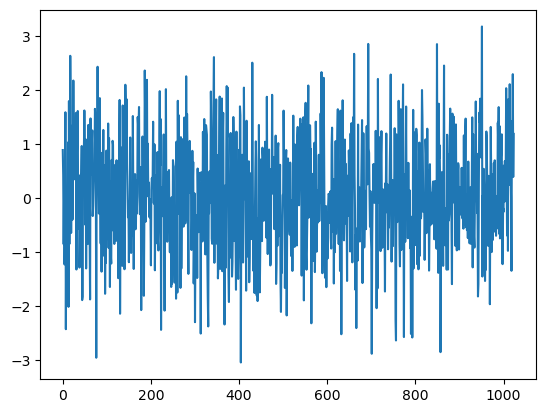

In [6]:
import numpy as np

def simulate_white_noise_unified(N, sigma=1.0):
    # Step 1: generate complex Gaussian white noise
    W = (np.random.normal(size=N) + 1j * np.random.normal(size=N)) / np.sqrt(2)
    
    # Step 2: enforce Hermitian symmetry via projection
    Z = (W + np.conj(np.roll(W[::-1], 1))) / np.sqrt(2)
    # Explanation:
    #   W[::-1]        -> [W_{N-1}, W_{N-2}, ..., W_0]
    #   roll(..., 1)   -> [W_0, W_{N-1}, ..., W_1] = [W_{(N-k) mod N}] for k=0,...,N-1
    #   conj           -> \overline{W_{(N-k) mod N}}
    
    # Step 3: scale by sigma
    Z = sigma * Z
    
    # Step 4: unitary inverse FFT
    X = np.fft.ifft(Z) * np.sqrt(N)
    
    return X.real  # imaginary part is ~0 (numerical error)

x = simulate_white_noise_unified(1000, sigma=2.0)
plt.plot(X)

# print(np.var(x))          # ≈ 4.0
# print(np.mean(x))         # ≈ 0
# print(np.corrcoef(x[:10], x[1:11])[0,1])  # ≈ 0 (uncorrelated)